Y-Achse reicht von -5.00 bis 1.00 °C
X-Achse reicht von 130.00 bis 250.00 °C


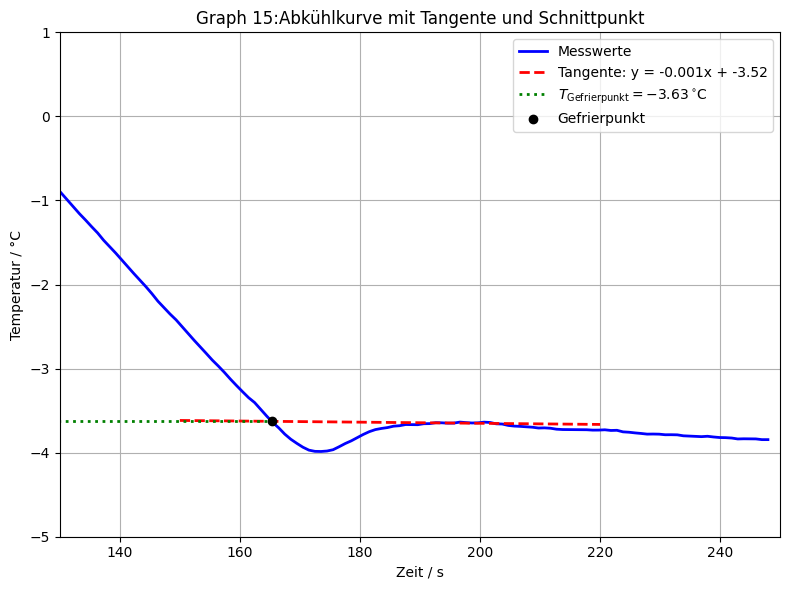

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Wasser + 10wt%.xlsx", engine="openpyxl",
                   usecols="Y,Z", skiprows=3, nrows=589)
df.columns = ["Zeit", "Temperatur"]

# ===============================
# Tangente bei ~300 s berechnen
# ===============================
# Bereich um die Tangente (angepasst!)
tangente_df = df[(df["Zeit"] >= 190) & (df["Zeit"] <= 205)]
x_tan = tangente_df["Zeit"].values
y_tan = tangente_df["Temperatur"].values
m, b = np.polyfit(x_tan, y_tan, deg=1)

# Tangente berechnen
x_line = np.linspace(150, 220, 200) #x_line = np.linspace(Startwert, Endwert, Punkte)
y_line = m * x_line + b

# ===============================
# Schnittpunkt mit Abkühlkurve (links der Tangente)
# ===============================
# Tangentenwert zu jedem Zeitpunkt berechnen
df["Tangente"] = m * df["Zeit"] + b
df["Delta"] = df["Temperatur"] - df["Tangente"]

# Suche den ersten echten Vorzeichenwechsel links des Tangentenbereichs
df_links = df[df["Zeit"] < 170]
delta_sign = np.sign(df_links["Delta"])
vorzeichenwechsel = np.where(np.diff(delta_sign))[0]

if len(vorzeichenwechsel) > 0:
    idx = vorzeichenwechsel[-1]  # der letzte Wechsel vor t=300
    # lineare Interpolation zwischen den beiden Punkten
    x1, x2 = df_links["Zeit"].iloc[idx], df_links["Zeit"].iloc[idx + 1]
    y1, y2 = df_links["Temperatur"].iloc[idx], df_links["Temperatur"].iloc[idx + 1]
    t1, t2 = df_links["Tangente"].iloc[idx], df_links["Tangente"].iloc[idx + 1]

    # Interpolierter Schnittpunkt (Temperatur = Tangente)
    delta1 = y1 - t1
    delta2 = y2 - t2
    x_schnitt = x1 - delta1 * (x2 - x1) / (delta2 - delta1)
    y_schnitt = m * x_schnitt + b
else:
    x_schnitt = np.nan
    y_schnitt = np.nan

# ===============================
# Plot
# ===============================
plt.figure(figsize=(8, 6))

# Originalkurve
plt.plot(df["Zeit"], df["Temperatur"], color='blue', linewidth=2, label='Messwerte')

# Tangente
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2,
         label=f"Tangente: y = {m:.3f}x + {b:.2f}")

# Horizontale ab Schnittpunkt
if not np.isnan(x_schnitt):
    plt.hlines(y_schnitt, xmin=0, xmax=x_schnitt, color='green', linestyle=':', linewidth=2,
           label = fr"$T_{{\mathrm{{Gefrierpunkt}}}} = {y_schnitt:.2f}\,^{{\circ}}\mathrm{{C}}$")
    plt.plot(x_schnitt, y_schnitt, 'ko', label="Gefrierpunkt")  # Punkt markieren

# Layout
plt.xlabel("Zeit / s")
plt.ylabel("Temperatur / °C")
plt.title("Graph 15:Abkühlkurve mit Tangente und Schnittpunkt")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Y-Achsenbereich ausgeben
y_limits = plt.ylim(-5, 1)
print(f"Y-Achse reicht von {y_limits[0]:.2f} bis {y_limits[1]:.2f} °C")

x_limits = plt.xlim(130, 250)
print(f"X-Achse reicht von {x_limits[0]:.2f} bis {x_limits[1]:.2f} °C")

plt.show()

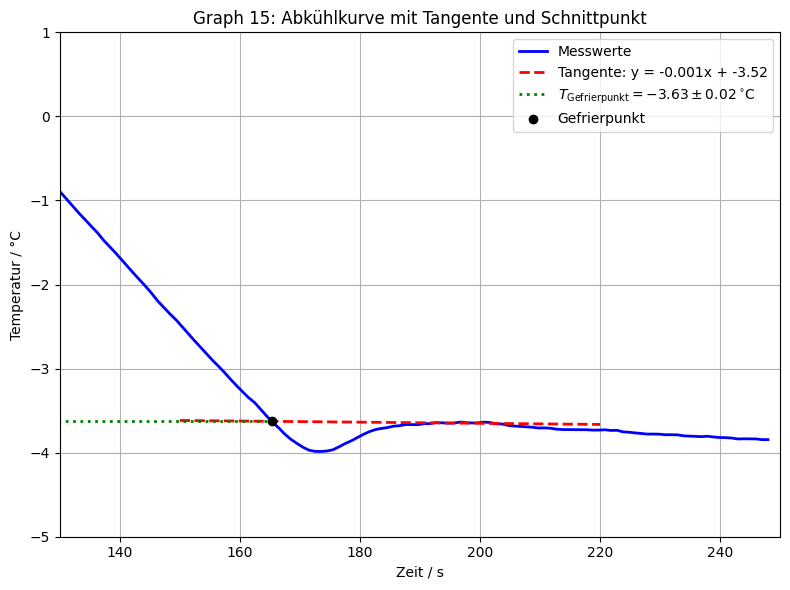

R² der Tangente           : 0.0886
Gefrierpunkt              : -3.63 ± 0.02 °C (1 σ)
Standardfehler (1 σ)      : ±0.02 °C
Fit-Parameter             : m = -0.00067 ± 0.00060,   b = -3.52 ± 0.12


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Wasser + 10wt%.xlsx", engine="openpyxl",
                   usecols="Y,Z", skiprows=3, nrows=589)
df.columns = ["Zeit", "Temperatur"]

# ===============================
# Tangentenfit im Bereich 190–205 s
# ===============================
mask = (df["Zeit"] >= 190) & (df["Zeit"] <= 205)
x_tan = df.loc[mask, "Zeit"].values
y_tan = df.loc[mask, "Temperatur"].values

def lin(x, m, b):
    return m * x + b

popt, pcov = curve_fit(lin, x_tan, y_tan)
m, b = popt
σ_m, σ_b = np.sqrt(np.diag(pcov))
cov_mb = pcov[0, 1]

# R² berechnen
y_pred = lin(x_tan, *popt)
ss_res = np.sum((y_tan - y_pred)**2)
ss_tot = np.sum((y_tan - np.mean(y_tan))**2)
r2 = 1 - ss_res / ss_tot

# ===============================
# Schnittpunkt links vom Fit
# ===============================
df["Tangente"] = lin(df["Zeit"], *popt)
df["Delta"] = df["Temperatur"] - df["Tangente"]

df_links = df[df["Zeit"] < 170]
wechsel = np.where(np.diff(np.sign(df_links["Delta"])))[0]

if len(wechsel):
    idx = wechsel[-1]
    x1, x2 = df_links["Zeit"].iloc[idx], df_links["Zeit"].iloc[idx + 1]
    y1, y2 = df_links["Temperatur"].iloc[idx], df_links["Temperatur"].iloc[idx + 1]
    t1, t2 = df_links["Tangente"].iloc[idx], df_links["Tangente"].iloc[idx + 1]

    delta1 = y1 - t1
    delta2 = y2 - t2
    x_schnitt = x1 - delta1 * (x2 - x1) / (delta2 - delta1)
    y_schnitt = lin(x_schnitt, *popt)

    # Fehlerfortpflanzung für den Schnittpunkt
    σ_y_schnitt = np.sqrt((x_schnitt ** 2) * σ_m**2 + σ_b**2 + 2 * x_schnitt * cov_mb)
else:
    x_schnitt = y_schnitt = σ_y_schnitt = np.nan

# ===============================
# Plot
# ===============================
plt.figure(figsize=(8, 6))

plt.plot(df["Zeit"], df["Temperatur"], color='blue', linewidth=2, label='Messwerte')

x_line = np.linspace(150, 220, 200)
plt.plot(x_line, lin(x_line, *popt), 'r--', linewidth=2, label=f"Tangente: y = {m:.3f}x + {b:.2f}")

if not np.isnan(x_schnitt):
    plt.hlines(y_schnitt, 0, x_schnitt, color='green', linestyle=':', linewidth=2,
               label=fr"$T_{{\mathrm{{Gefrierpunkt}}}} = {y_schnitt:.2f} \pm {σ_y_schnitt:.2f}\,^{{\circ}}\mathrm{{C}}$")
    plt.plot(x_schnitt, y_schnitt, 'ko', label="Gefrierpunkt")

plt.xlabel("Zeit / s")
plt.ylabel("Temperatur / °C")
plt.title("Graph 15: Abkühlkurve mit Tangente und Schnittpunkt")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.ylim(-5, 1)
plt.xlim(130, 250)
plt.show()

# ===============================
# Konsole
# ===============================
print(f"R² der Tangente           : {r2:.4f}")
print(f"Gefrierpunkt              : {y_schnitt:.2f} ± {σ_y_schnitt:.2f} °C (1 σ)")
print(f"Standardfehler (1 σ)      : ±{σ_y_schnitt:.2f} °C")
print(f"Fit-Parameter             : m = {m:.5f} ± {σ_m:.5f},   b = {b:.2f} ± {σ_b:.2f}")